In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))  # or "." depending on location

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             roc_curve, roc_auc_score,
                             precision_recall_curve, auc)


from src.pipeline import build_pipeline

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/ananyaghorpade29/titanic/refs/heads/main/data/Titanic-Dataset.csv")
df.head()

x= df.drop(["Survived", "Name", "Ticket", "Cabin", "PassengerId"], axis=1)
y= df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

categorical_cols = ["Sex", "Embarked"]
numerical_cols = ["Age", "Fare", "Pclass", "SibSp", "Parch"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

pipelines = {
    "RandomForest":        build_pipeline(RandomForestClassifier(random_state=42)),
    "XGBoost":             build_pipeline(XGBClassifier(eval_metric='logloss', random_state=42)),
    "LightGBM":            build_pipeline(LGBMClassifier(random_state=42, verbose=-1)),
    "LogisticRegression":  build_pipeline(LogisticRegression(max_iter=1000)),
    "DecisionTree":        build_pipeline(DecisionTreeClassifier(random_state=42)),
}
print("Pipelines ready:", list(pipelines.keys()))

baseline_results = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    baseline_results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4)
    })

baseline_df = pd.DataFrame(baseline_results).sort_values("F1 Score", ascending=False)
print("\n Baseline Model Comparison:")
print(baseline_df.to_string(index=False))

Train size: (712, 7) | Test size: (179, 7)
Pipelines ready: ['RandomForest', 'XGBoost', 'LightGBM', 'LogisticRegression', 'DecisionTree']

 Baseline Model Comparison:
             Model  Accuracy  F1 Score
          LightGBM    0.8268    0.7891
      RandomForest    0.8212    0.7746
           XGBoost    0.8101    0.7671
LogisticRegression    0.8101    0.7639
      DecisionTree    0.7933    0.7517


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [5]:
rf_pipeline = build_pipeline(
    RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=2,
        random_state=42
    )
)

xgb_pipeline = build_pipeline(
    XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
)

lgbm_pipeline = build_pipeline(
    LGBMClassifier(random_state=42)
)

log_pipeline = build_pipeline(
    LogisticRegression(max_iter=1000)
)

dt_pipeline = build_pipeline(
    DecisionTreeClassifier(random_state=42)
)

In [6]:
models = {
    "RandomForest (Tuned)": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "LightGBM": lgbm_pipeline,
    "Logistic Regression": log_pipeline,
    "Decision Tree": dt_pipeline
}

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [19:45:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


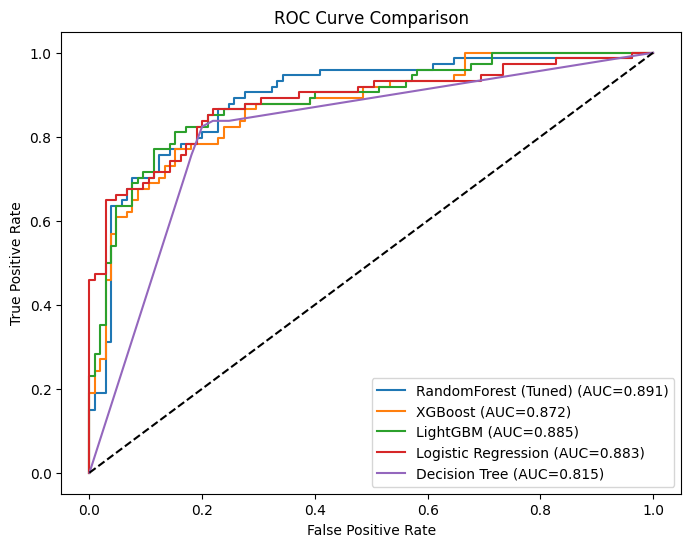

In [7]:
#ROC Curve (ALL MODELS
plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_probs = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


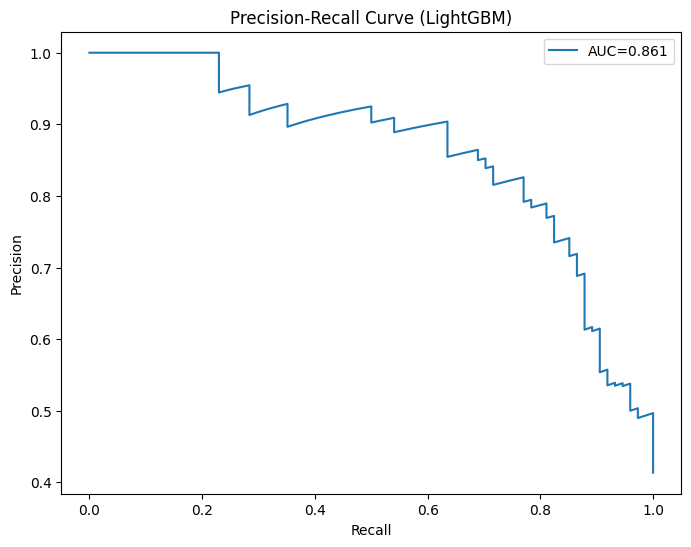

In [8]:
#Precision-Recall curve  ALL MODELS
best_model = lgbm_pipeline

best_model.fit(X_train, y_train)
y_probs = best_model.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f"AUC={pr_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (LightGBM)")
plt.legend()

plt.show()

In [9]:
#threshold
thresholds = [0.4, 0.5, 0.6]

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)

    from sklearn.metrics import precision_score, recall_score

    print(f"\nThreshold = {t}")
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))


Threshold = 0.4
Precision: 0.7530864197530864
Recall: 0.8243243243243243

Threshold = 0.5
Precision: 0.7945205479452054
Recall: 0.7837837837837838

Threshold = 0.6
Precision: 0.8181818181818182
Recall: 0.7297297297297297
